In [ ]:
!pip install pyspark --quiet
print('PySpark installation Successfully!!')
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year,month,to_date,col,round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


PySpark installation Successfully!!


In [ ]:
#create spark session
spark=SparkSession.builder\
.appName('Day4_BigData_sales')\
.config('spark.sql.adaptive.enabled','true')\
.getOrCreate()

print(f'Spark Version: {spark.version}')
print(f'Spark Session: ACTIVE')
print(f'Application Name: {spark.sparkContext.appName}')

Spark Version: 4.0.2
Spark Session: ACTIVE
Application Name: Day4_BigData_sales


In [ ]:
df_bronze=spark.read\
.option('header','true')\
.option('interSchema','true')\
.csv('/content/drive/MyDrive/Copy of large_sales_data.csv')

print('BRONZE LAYER')
print(f'Rows: {df_bronze.count()}')
print(f'Columns: {len(df_bronze.columns)}')
print(F'Names: {df_bronze.columns}')
print() #just for blank space between lines
df_bronze.printSchema()

BRONZE LAYER
Rows: 5000
Columns: 13
Names: ['order_id', 'customer_name', 'product', 'category', 'quantity', 'unit_price', 'revenue', 'order_date', 'city', 'region', 'sales_rep', 'payment_method', 'order_status']

root
 |-- order_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: string (nullable = true)
 |-- unit_price: string (nullable = true)
 |-- revenue: string (nullable = true)
 |-- order_date: string (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
df_bronze.tail(5)

[Row(order_id='5996', customer_name='Ananya Das', product='Mouse', category='Accessories', quantity='13', unit_price='800', revenue='10400', order_date='2023-11-18', city='Bangalore', region='South', sales_rep='Meera Patel', payment_method='Net Banking', order_status='Cancelled'),
 Row(order_id='5997', customer_name='Suresh Rao', product='Webcam', category='Accessories', quantity='9', unit_price='2500', revenue='22500', order_date='2023-06-07', city='Chennai', region='South', sales_rep='Sunita Rao', payment_method='Credit Card', order_status='Delivered'),
 Row(order_id='5998', customer_name='Arjun Nair', product='Webcam', category='Accessories', quantity='1', unit_price='2500', revenue='2500', order_date='2023-04-07', city='Jaipur', region='North', sales_rep='Kavya Reddy', payment_method='Net Banking', order_status='Cancelled'),
 Row(order_id='5999', customer_name='Arjun Nair', product='Laptop', category='Electronics', quantity='14', unit_price='45000', revenue='630000', order_date='20

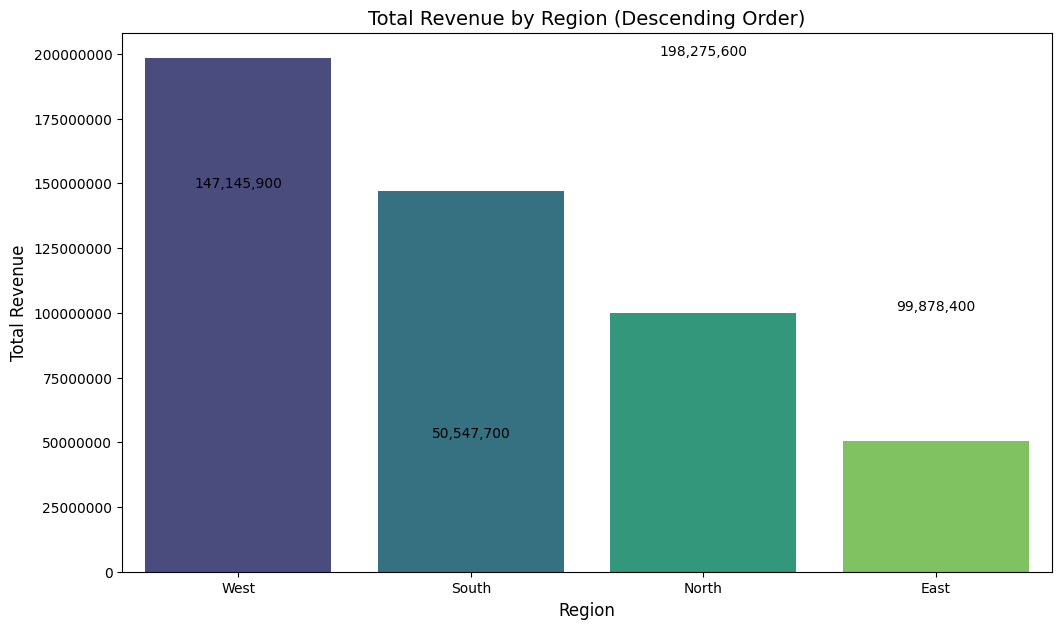

In [ ]:
df_bronze_clean = df_bronze.withColumn('revenue', df_bronze['revenue'].cast('double'))

# Aggregate total revenue by region
revenue_by_region = df_bronze_clean.groupBy('region').agg(F.sum('revenue').alias('total_revenue'))

# Convert to Pandas DataFrame for plotting
revenue_by_region_pd = revenue_by_region.toPandas()

# Sort the DataFrame by 'total_revenue' in descending order
revenue_by_region_pd = revenue_by_region_pd.sort_values(by='total_revenue', ascending=False)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='region', y='total_revenue', data=revenue_by_region_pd, palette='viridis')
plt.title('Total Revenue by Region (Descending Order)', fontsize=14)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis

# Add revenue amounts on top of each bar, formatting as integer with commas
for index, row in revenue_by_region_pd.iterrows():
    plt.text(index, row['total_revenue'], f'{int(row['total_revenue']):,}', color='black', ha="center", va='bottom')

plt.show()